Optimal launch angle under drag (RK4): 34.34 degrees


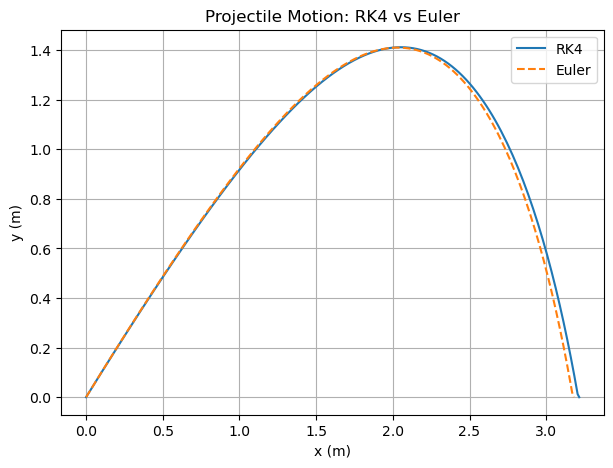

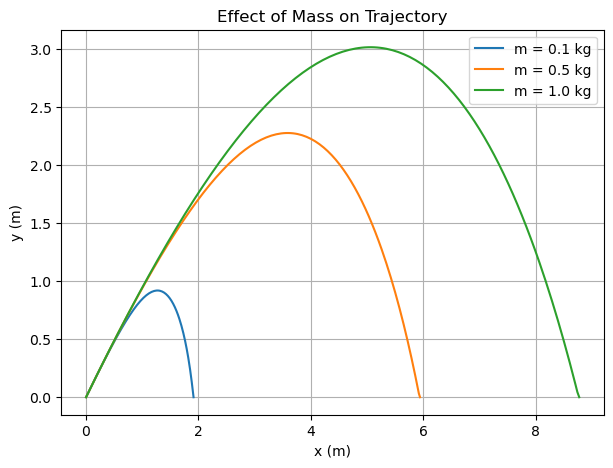

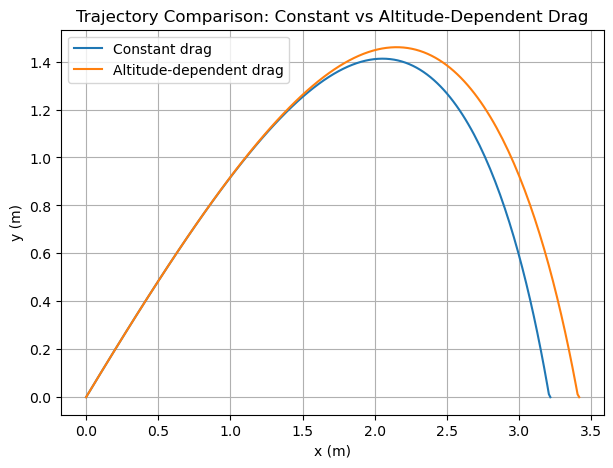

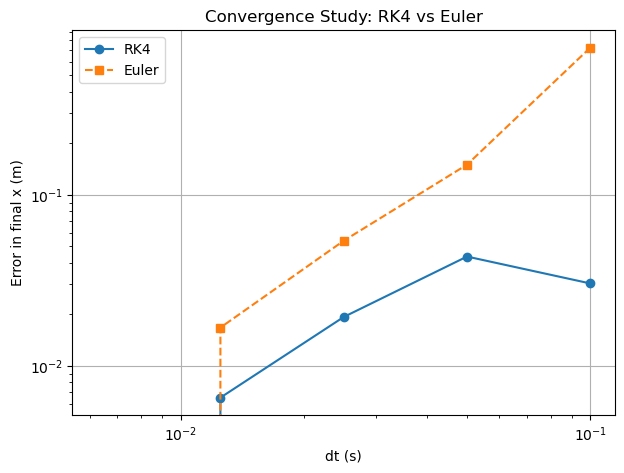

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

# -----------------------------
# 1. ODE Functions
# -----------------------------
def projectile_ode(t, y, k, m, g):
    """Quadratic drag, constant k"""
    x, y_pos, vx, vy = y
    speed = np.sqrt(vx**2 + vy**2)
    dxdt = vx
    dydt = vy
    dvxdt = -(k/m) * speed * vx
    dvydt = -g - (k/m) * speed * vy
    return np.array([dxdt, dydt, dvxdt, dvydt])

def projectile_ode_altitude(t, y, k0, H, m, g):
    """Quadratic drag decreasing with altitude: k(y) = k0 * exp(-y/H)"""
    x, y_pos, vx, vy = y
    k = k0 * np.exp(-y_pos / H)
    speed = np.sqrt(vx**2 + vy**2)
    dxdt = vx
    dydt = vy
    dvxdt = -(k/m) * speed * vx
    dvydt = -g - (k/m) * speed * vy
    return np.array([dxdt, dydt, dvxdt, dvydt])

# -----------------------------
# 2. RK4 Solver
# -----------------------------
def rk4_step(f, t, y, dt, *args):
    k1 = f(t, y, *args)
    k2 = f(t + dt/2, y + dt/2 * k1, *args)
    k3 = f(t + dt/2, y + dt/2 * k2, *args)
    k4 = f(t + dt, y + dt * k3, *args)
    return y + dt/6 * (k1 + 2*k2 + 2*k3 + k4)

# -----------------------------
# 3. Euler Solver
# -----------------------------
def euler_step(f, t, y, dt, *args):
    return y + dt * f(t, y, *args)

# -----------------------------
# 4. Trajectory Simulation
# -----------------------------
def simulate_trajectory(f, y0, dt, t_max, *args, method='RK4'):
    """Simulate trajectory using RK4 or Euler"""
    num_steps = int(t_max / dt)
    traj = np.zeros((num_steps+1, 4))
    traj[0] = y0.copy()
    y = y0.copy()
    for i in range(num_steps):
        if method.upper() == 'RK4':
            y = rk4_step(f, i*dt, y, dt, *args)
        elif method.upper() == 'EULER':
            y = euler_step(f, i*dt, y, dt, *args)
        else:
            raise ValueError("Method must be 'RK4' or 'Euler'")
        if y[1] < 0:  # stop at ground
            y[1] = 0
            traj[i+1:] = y
            break
        traj[i+1] = y
    return traj

# -----------------------------
# 5. General Run Function
# -----------------------------
def run_simulation(m=0.2, k=0.1, g=9.81,
                   y0=np.array([0.0,0.0,10.0,10.0]),
                   dt=0.01, t_max=2.0,
                   method='RK4', altitude=False, H=10.0):
    """General simulation runner"""
    if altitude:
        traj = simulate_trajectory(projectile_ode_altitude, y0, dt, t_max, k, H, m, g, method=method)
    else:
        traj = simulate_trajectory(projectile_ode, y0, dt, t_max, k, m, g, method=method)
    return traj

# -----------------------------
# 6. Convergence Study
# -----------------------------
def convergence_test(y0, t_max, dt_values, m, k, g, method='RK4', altitude=False, H=10.0):
    final_positions = []
    for dt in dt_values:
        traj = run_simulation(m=m, k=k, g=g, y0=y0, dt=dt, t_max=t_max, method=method,
                              altitude=altitude, H=H)
        final_positions.append(traj[-1,0])
    return final_positions

# -----------------------------
# 7. Launch Angle Optimization
# -----------------------------
def simulate_range(angle_deg, speed, m, k, g, dt=0.01, method='RK4'):
    angle = np.radians(angle_deg)
    y0 = np.array([0.0, 0.0, speed*np.cos(angle), speed*np.sin(angle)])
    traj = run_simulation(m=m, k=k, g=g, y0=y0, dt=dt, t_max=10.0, method=method)
    return traj[-1,0]

def find_optimal_angle(speed, m, k, g, dt=0.01, method='RK4'):
    res = minimize_scalar(lambda ang: -simulate_range(ang, speed, m, k, g, dt=dt, method=method),
                          bounds=(0,90), method='bounded')
    return res.x

# -----------------------------
# 8. Example Usage & Parameter Sweep
# -----------------------------
if __name__ == "__main__":
    # Default parameters
    y0 = np.array([0.0,0.0,10.0,10.0])
    dt = 0.01
    t_max = 2.0

    # Run RK4 vs Euler for default parameters
    traj_rk4 = run_simulation(y0=y0, dt=dt, t_max=t_max, method='RK4')
    traj_euler = run_simulation(y0=y0, dt=dt, t_max=t_max, method='Euler')

    plt.figure(figsize=(7,5))
    plt.plot(traj_rk4[:,0], traj_rk4[:,1], label='RK4')
    plt.plot(traj_euler[:,0], traj_euler[:,1], label='Euler', linestyle='--')
    plt.xlabel('x (m)')
    plt.ylabel('y (m)')
    plt.title('Projectile Motion: RK4 vs Euler')
    plt.legend()
    plt.grid()

    # Parameter sweep: different masses
    m_values = [0.1, 0.5, 1.0]
    plt.figure(figsize=(7,5))
    for m_val in m_values:
        traj = run_simulation(m=m_val, y0=y0, dt=dt, t_max=t_max)
        plt.plot(traj[:,0], traj[:,1], label=f'm = {m_val} kg')
    plt.xlabel('x (m)')
    plt.ylabel('y (m)')
    plt.title('Effect of Mass on Trajectory')
    plt.legend()
    plt.grid()

    # Altitude-dependent drag
    traj_alt = run_simulation(y0=y0, dt=dt, t_max=t_max, method='RK4', altitude=True, H=10.0)
    plt.figure(figsize=(7,5))
    plt.plot(traj_rk4[:,0], traj_rk4[:,1], label='Constant drag')
    plt.plot(traj_alt[:,0], traj_alt[:,1], label='Altitude-dependent drag')
    plt.xlabel('x (m)')
    plt.ylabel('y (m)')
    plt.title('Trajectory Comparison: Constant vs Altitude-Dependent Drag')
    plt.legend()
    plt.grid()

    # Convergence example
    dt_values = [0.1,0.05,0.025,0.0125,0.00625]
    final_rk4 = convergence_test(y0, t_max, dt_values, m=0.2, k=0.1, g=9.81, method='RK4')
    final_euler = convergence_test(y0, t_max, dt_values, m=0.2, k=0.1, g=9.81, method='Euler')
    plt.figure(figsize=(7,5))
    plt.loglog(dt_values, np.abs(final_rk4[-1]-np.array(final_rk4)), 'o-', label='RK4')
    plt.loglog(dt_values, np.abs(final_euler[-1]-np.array(final_euler)), 's--', label='Euler')
    plt.xlabel('dt (s)')
    plt.ylabel('Error in final x (m)')
    plt.title('Convergence Study: RK4 vs Euler')
    plt.legend()
    plt.grid()

    # Optimal launch angle
    optimal_angle = find_optimal_angle(speed=10.0, m=0.2, k=0.1, g=9.81)
    print(f"Optimal launch angle under drag (RK4): {optimal_angle:.2f} degrees")

    plt.show()